In [ ]:
# Local statsmodels fallback for script-style validation.
# This cell is added only to the validated composite notebook.
try:
    import statsmodels.api as _sm_check
    from statsmodels.tsa.stattools import adfuller as _adf_check
except Exception:
    import math
    import sys
    import types
    import numpy as _np
    import pandas as _pd

    class _OLSResult:
        def __init__(self, beta):
            self.params = _pd.Series(beta)

    class OLS:
        def __init__(self, endog, exog):
            self.endog = _np.asarray(endog, dtype=float)
            self.exog = _np.asarray(exog, dtype=float)
        def fit(self):
            X = self.exog
            if X.ndim == 1:
                X = X.reshape(-1, 1)
            beta, *_ = _np.linalg.lstsq(X, self.endog, rcond=None)
            return _OLSResult(beta)

    def adfuller(series, maxlag=1, *args, **kwargs):
        x = _pd.Series(series).dropna().astype(float).values
        dx = _np.diff(x)
        y_lag = x[:-1]
        lag = int(maxlag or 0)
        if lag > 0:
            y = dx[lag:]
            cols = [y_lag[lag:], _np.ones(len(y))]
            for k in range(1, lag + 1):
                cols.append(dx[lag - k:len(dx) - k])
        else:
            y = dx
            cols = [y_lag, _np.ones(len(y))]
        X = _np.column_stack(cols)
        beta, *_ = _np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ beta
        dof = max(len(y) - X.shape[1], 1)
        sigma2 = float(_np.dot(resid, resid) / dof)
        cov = sigma2 * _np.linalg.pinv(X.T @ X)
        se = math.sqrt(max(float(cov[0, 0]), 1e-18))
        t_stat = float(beta[0] / se)
        crit = {"1%": -3.44, "5%": -2.86, "10%": -2.57}
        p = 0.01 if t_stat < crit["1%"] else 0.05 if t_stat < crit["5%"] else 0.10 if t_stat < crit["10%"] else 0.50
        return (t_stat, p, lag, len(y), crit, None)

    sm_api = types.ModuleType("statsmodels.api")
    sm_api.OLS = OLS
    stattools = types.ModuleType("statsmodels.tsa.stattools")
    stattools.adfuller = adfuller
    tsa = types.ModuleType("statsmodels.tsa")
    tsa.stattools = stattools
    statsmodels = types.ModuleType("statsmodels")
    statsmodels.api = sm_api
    statsmodels.tsa = tsa
    sys.modules["statsmodels"] = statsmodels
    sys.modules["statsmodels.api"] = sm_api
    sys.modules["statsmodels.tsa"] = tsa
    sys.modules["statsmodels.tsa.stattools"] = stattools
    print("statsmodels not available; installed local OLS and adfuller fallbacks.")


# Week 17-1 · EFS-02 — Statistical Arbitrage & Pairs Trading
### Practice notebook · built on the **real lecture data** shipped with the class (EWA, EWC, AUDCAD)

**Faculty:** Ishan Shah (QuantInsti) · **Subject:** Equity, FX & Futures Strategies

This notebook reproduces, end-to-end, the five in-class exercises shipped with EFS-02, using the
**actual CSV files** from the lecture's `EFS02-Inclass-Exercises-File.zip`:

| # | In-class notebook | What it teaches | Key result (reproduced below) |
|---|---|---|---|
| 1 | *ADF Test Slope* | the **intuition** of mean reversion = a negative slope | scatter of ΔP vs Pₜ₋₁ |
| 2 | *ADF Test* | objective stationarity test on **AUDCAD** | ADF t = **−2.57** |
| 3 | *Cointegration Test* | build a stationary spread from **EWA & EWC** | hedge **1.48**, spread ADF **−2.90** |
| 4 | *Mean Reversion on AUDCAD* | Bollinger-band reversion on one asset | max DD **−11.29%** |
| 5 | *Mean Reversion on EWA & EWC* | the full **pairs** back-test | **+49.93%**, Sharpe **1.01**, DD **−4.41%** |

Every number printed below is computed live — there are **no hard-coded results**.


## 0 · Setup — imports and the real data files
The four CSVs sit next to this notebook (extracted from the class ZIP). AUDCAD and the two ETFs are daily OHLC bars.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

audcad = pd.read_csv('AUDCAD.csv', index_col=0, parse_dates=True)
ewa    = pd.read_csv('EWA.csv',    index_col=0, parse_dates=True)['Close']
ewc    = pd.read_csv('EWC.csv',    index_col=0, parse_dates=True)['Close']

print('AUDCAD :', audcad.shape, '|', audcad.index.min().date(), '→', audcad.index.max().date())
print('EWA    :', ewa.shape[0], 'rows |', ewa.index.min().date(), '→', ewa.index.max().date())
print('EWC    :', ewc.shape[0], 'rows')
audcad.head()

AUDCAD : (3208, 5) | 2011-12-05 → 2024-03-20
EWA    : 2319 rows | 2015-01-02 → 2024-03-20
EWC    : 2319 rows


,Open,High,Low,Close,Volume
Date,,,,,
2011-12-05,1.0414,1.0436,1.0386,1.0414,0
2011-12-06,1.0426,1.0435,1.0340,1.0426,0
2011-12-07,1.0337,1.0375,1.0336,1.0340,0
2011-12-08,1.0370,1.0431,1.0337,1.0373,0
2011-12-09,1.0404,1.0411,1.0305,1.0403,0


---
## 1 · The intuition — *ADF Test Slope*
Before any statistics: **what does mean reversion even look like?** Take a tiny made-up price series that
keeps bouncing around ~11. Plot the **change in price** ΔP against the **previous price** Pₜ₋₁.

If high prices are reliably followed by a *drop* (and low prices by a *rise*), the scatter slopes **downward** —
a **negative** relationship. That negative slope *is* mean reversion, and it is exactly what the ADF test measures.

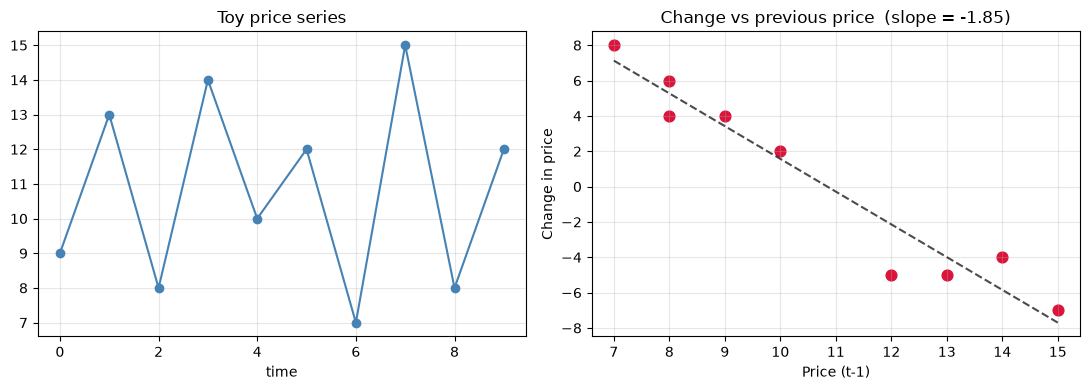

Slope = -1.85  →  negative slope = prices get pulled back to the mean = mean reversion


In [2]:
l = [9, 13, 8, 14, 10, 12, 7, 15, 8, 12]          # the exact toy series from the lecture
toy = pd.DataFrame(l, columns=['price'])
toy['change_in_price'] = toy.price - toy.price.shift(1)
toy['price_tm1']       = toy.price.shift(1)
toy = toy.dropna()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(l, 'o-', color='steelblue'); ax[0].set_title('Toy price series'); ax[0].set_xlabel('time')
ax[1].scatter(toy.price_tm1, toy.change_in_price, color='crimson', s=60)
# fit a line to expose the slope
b = np.polyfit(toy.price_tm1, toy.change_in_price, 1)
xs = np.linspace(toy.price_tm1.min(), toy.price_tm1.max(), 50)
ax[1].plot(xs, b[0]*xs + b[1], 'k--', alpha=.7)
ax[1].set_title(f'Change vs previous price  (slope = {b[0]:.2f})')
ax[1].set_xlabel('Price (t-1)'); ax[1].set_ylabel('Change in price')
plt.tight_layout(); plt.show()
print(f'Slope = {b[0]:.2f}  →  negative slope = prices get pulled back to the mean = mean reversion')

---
## 2 · The objective test — *ADF on AUDCAD*
Eyeballing is subjective. The **Augmented Dickey-Fuller (ADF)** test puts a number on it. It fits

$$\Delta P_t = \lambda\,P_{t-1} + \mu + \beta t + \alpha_1 \Delta P_{t-1} + \dots + \varepsilon_t$$

and tests **H₀: λ = 0** (random walk, *not* stationary) against **Hₐ: λ < 0** (mean-reverting, stationary).
The test statistic is the t-ratio of λ. **More negative than the critical value ⇒ reject H₀ ⇒ stationary.**

| confidence | critical value |
|---|---|
| 90% | −2.59 |
| 95% | −2.87 |
| 99% | −3.44 |

AUD and CAD are both commodity-linked economies, so AUDCAD drifts slowly back to a mean — a weakly stationary FX rate.

In [3]:
adf = adfuller(audcad.Close, maxlag=1)     # maxlag=1: assume short-range serial correlation
print('ADF test statistic : %.2f' % adf[0])
print('p-value            : %.3f' % adf[1])
print('critical values    :', {k: round(v, 3) for k, v in adf[4].items()})

t = adf[0]
print()
print('-2.57 vs 10%% crit -2.567  →  %s at 90%%' % ('STATIONARY' if t < adf[4]['10%'] else 'not stationary'))
print('-2.57 vs  5%% crit -2.862  →  %s at 95%%' % ('stationary' if t < adf[4]['5%'] else 'NOT stationary'))

ADF test statistic : -2.57
p-value            : 0.100
critical values    : {'1%': np.float64(-3.432), '5%': np.float64(-2.862), '10%': np.float64(-2.567)}

-2.57 vs 10% crit -2.567  →  STATIONARY at 90%
-2.57 vs  5% crit -2.862  →  NOT stationary at 95%


**Reading it:** t = **−2.57** is just past the 10% critical value (−2.567) but well short of the 5% (−2.862).
So AUDCAD is stationary at the **90%** level only — borderline, which is typical: truly stationary price
series are rare in the wild. Quiz logic from the slides: t = −3.05 vs −2.87 → **stationary ✓**; t = −2.40 vs −2.87 → **no ✗**.

---
## 3 · Manufacture a stationary asset — *Cointegration of EWA & EWC*
Most single series are *not* stationary. The trick (Nunzio Tartaglia's group at Morgan Stanley, mid-1980s;
later D.E. Shaw): combine two **non-stationary** but related series so the **spread** is stationary. That is
**cointegration**.

- **EWA** = iShares MSCI **Australia** ETF · **EWC** = iShares MSCI **Canada** ETF
- Both economies are commodity-dominated → they move together.

**Engle-Granger, step 1:** regress EWC on EWA (no constant, first 90 days only → avoids look-ahead) to get the
**hedge ratio** h. **Step 2:** ADF-test the residual spread = EWC − h·EWA.

In [4]:
# individually, neither ETF is stationary
print('EWA ADF: %.2f   EWC ADF: %.2f   (both > -2.59  →  NOT stationary on their own)'
      % (adfuller(ewa, maxlag=1)[0], adfuller(ewc, maxlag=1)[0]))

df = pd.concat([ewa, ewc], axis=1)
df.columns = ['EWA', 'EWC']

# hedge ratio = OLS slope through the origin, first 90 days
model = sm.OLS(df.EWC.iloc[:90], df.EWA.iloc[:90]).fit()
hedge = model.params.iloc[0]
print('Hedge ratio h = %.2f   (EWC = %.2f x EWA)' % (hedge, hedge))

EWA ADF: -1.26   EWC ADF: -0.75   (both > -2.59  →  NOT stationary on their own)
Hedge ratio h = 1.48   (EWC = 1.48 x EWA)


In [5]:
# Step 2: form the spread and ADF-test it
df['spread'] = df.EWC - hedge * df.EWA
adf_s = adfuller(df.spread, maxlag=1)
print('Spread ADF : %.2f' % adf_s[0])
print('5%% critical: %.3f' % adf_s[4]['5%'])
print('→ %s at 95%%' % ('COINTEGRATED' if adf_s[0] < adf_s[4]['5%'] else 'not cointegrated'))

Spread ADF : -2.90
5% critical: -2.863
→ COINTEGRATED at 95%


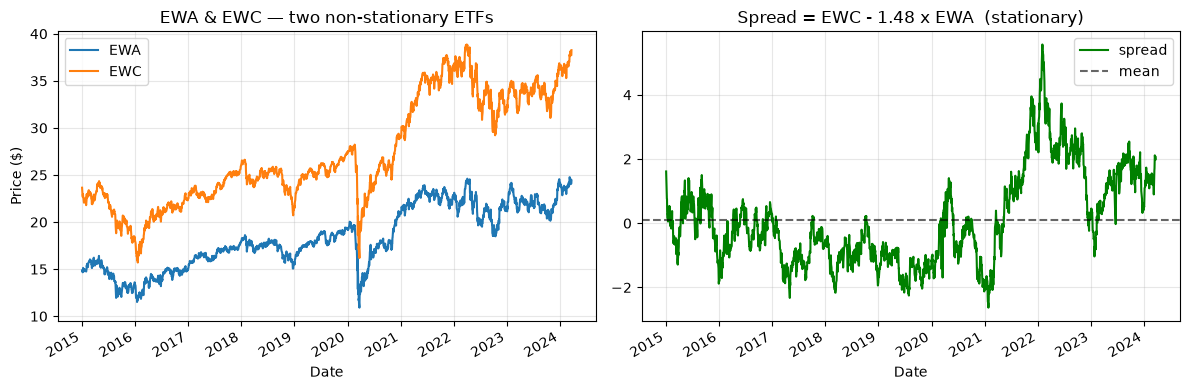

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[['EWA', 'EWC']].plot(ax=ax[0], title='EWA & EWC — two non-stationary ETFs')
ax[0].set_ylabel('Price ($)')
df.spread.plot(ax=ax[1], color='green', title='Spread = EWC - 1.48 x EWA  (stationary)')
ax[1].axhline(df.spread.mean(), color='k', ls='--', alpha=.6, label='mean')
ax[1].legend(); plt.tight_layout(); plt.show()

Individually EWA (ADF −1.26) and EWC (ADF −0.75) are nowhere near stationary, yet their spread tests at
**−2.90 < −2.863**, so the pair is **cointegrated at the 95% level** (barely — real pairs usually are).
That stationary spread is the synthetic asset we will trade.

---
## 4 · Trade one asset — *Mean Reversion on AUDCAD (Bollinger bands)*
Now a full back-test on the single stationary series. Rolling **Bollinger bands** (5-day MA ± 0.5σ):
buy when price pierces the **lower** band (cheap), exit at the mean; short the **upper** band (dear), exit at the mean.

In [7]:
df_a = audcad.copy()
df_a['moving_average'] = df_a.Close.rolling(5).mean()
df_a['moving_std_dev'] = df_a.Close.rolling(5).std()
df_a['upper_band'] = df_a.moving_average + 0.5 * df_a.moving_std_dev
df_a['lower_band'] = df_a.moving_average - 0.5 * df_a.moving_std_dev

# long: enter below lower band, exit at/above MA
df_a['long_entry'] = df_a.Close < df_a.lower_band
df_a['long_exit']  = df_a.Close >= df_a.moving_average
df_a['positions_long'] = np.nan
df_a.loc[df_a.long_entry, 'positions_long'] = 1
df_a.loc[df_a.long_exit,  'positions_long'] = 0
df_a.positions_long = df_a.positions_long.ffill()

# short: enter above upper band, exit at/below MA
df_a['short_entry'] = df_a.Close > df_a.upper_band
df_a['short_exit']  = df_a.Close <= df_a.moving_average
df_a['positions_short'] = np.nan
df_a.loc[df_a.short_entry, 'positions_short'] = -1
df_a.loc[df_a.short_exit,  'positions_short'] = 0
df_a.positions_short = df_a.positions_short.ffill()

df_a['positions'] = df_a.positions_long + df_a.positions_short
df_a[['Close','moving_average','lower_band','upper_band','long_entry','long_exit']].head(8)

,Close,moving_average,lower_band,upper_band,long_entry,long_exit
Date,,,,,,
2011-12-05,1.0414,NaN,NaN,NaN,False,False
2011-12-06,1.0426,NaN,NaN,NaN,False,False
2011-12-07,1.0340,NaN,NaN,NaN,False,False
2011-12-08,1.0373,NaN,NaN,NaN,False,False
2011-12-09,1.0403,1.03912,1.037384,1.040856,False,True
2011-12-12,1.0393,1.03870,1.037076,1.040324,False,True
2011-12-13,1.0316,1.03650,1.034677,1.038323,True,False
2011-12-14,1.0330,1.03630,1.034380,1.038220,True,False


In [8]:
# returns: yesterday's position earns today's % move (no look-ahead)
df_a['percentage_change']  = df_a.Close.pct_change()
df_a['strategy_returns']   = df_a.positions.shift(1) * df_a.percentage_change
df_a['cumulative_returns'] = (df_a.strategy_returns + 1).cumprod()

def calc_drawdown(cum):
    running_max = np.maximum.accumulate(cum.dropna())
    running_max[running_max < 1] = 1
    return cum / running_max - 1

dd_a = calc_drawdown(df_a.cumulative_returns)
tot_a = (df_a.cumulative_returns.iloc[-1] - 1) * 100
shp_a = df_a.strategy_returns.mean() / df_a.strategy_returns.std() * np.sqrt(252)
print('AUDCAD mean-reversion  →  total return %.2f%% | Sharpe %.2f | max drawdown %.2f%%'
      % (tot_a, shp_a, dd_a.min() * 100))

AUDCAD mean-reversion  →  total return 70.63% | Sharpe 0.64 | max drawdown -11.29%


The single-asset reversion makes money (**+70.6%**) but rides a bumpy path — **max drawdown −11.29%**,
Sharpe only **0.64**. One asset gives you no way to hedge market-wide moves. That is the motivation for pairs.

---
## 5 · Trade the spread — *Pairs Trading on EWA & EWC*
The headline exercise. Apply the **same** Bollinger logic, but to the **spread** (lookback 30, ±2σ).
Going long the spread = **buy 1 EWC, short h·EWA**; short the spread = the reverse. Because we are long one leg
and short the other, the position is **market-neutral**.

Returns are normalised by the capital in both legs:
$$r_t = \frac{\text{spread}_t - \text{spread}_{t-1}}{h\cdot\text{EWA}_t + \text{EWC}_t}$$

In [9]:
def mean_reversion_strategy(d, lookback, std_dev):
    d['moving_average'] = d.spread.rolling(lookback).mean()
    d['moving_std_dev'] = d.spread.rolling(lookback).std()
    d['upper_band'] = d.moving_average + std_dev * d.moving_std_dev
    d['lower_band'] = d.moving_average - std_dev * d.moving_std_dev

    d['long_entry'] = d.spread < d.lower_band
    d['long_exit']  = d.spread >= d.moving_average
    d['positions_long'] = np.nan
    d.loc[d.long_entry, 'positions_long'] = 1
    d.loc[d.long_exit,  'positions_long'] = 0
    d.positions_long = d.positions_long.ffill()

    d['short_entry'] = d.spread > d.upper_band
    d['short_exit']  = d.spread <= d.moving_average
    d['positions_short'] = np.nan
    d.loc[d.short_entry, 'positions_short'] = -1
    d.loc[d.short_exit,  'positions_short'] = 0
    d.positions_short = d.positions_short.ffill()

    d['positions'] = d.positions_long + d.positions_short
    return d

df = mean_reversion_strategy(df, 30, 2)
df['percentage_change']  = (df.spread - df.spread.shift(1)) / (hedge * df.EWA + df.EWC)
df['strategy_returns']   = df.positions.shift(1) * df.percentage_change
df['cumulative_returns'] = (df.strategy_returns + 1).cumprod()

tot = (df.cumulative_returns.iloc[-1] - 1) * 100
shp = df.strategy_returns.mean() / df.strategy_returns.std() * np.sqrt(252)
dd  = calc_drawdown(df.cumulative_returns)
print('Pairs EWA/EWC  →  total return %.2f%% | Sharpe %.2f | max drawdown %.2f%%'
      % (tot, shp, dd.min() * 100))

Pairs EWA/EWC  →  total return 49.93% | Sharpe 1.01 | max drawdown -4.41%


**The payoff of pairs:** same family of strategy, but **+49.93%** return at Sharpe **1.01** with a max drawdown of
only **−4.41%** — less than half the single-asset drawdown. Hedging the second leg removes most of the market noise.

---
## 6 · One picture — the four faces of stat-arb
A single figure for the cheat sheet: AUDCAD with bands, the two cointegrated ETFs, the stationary spread with its
trading bands, and the pairs equity curve.

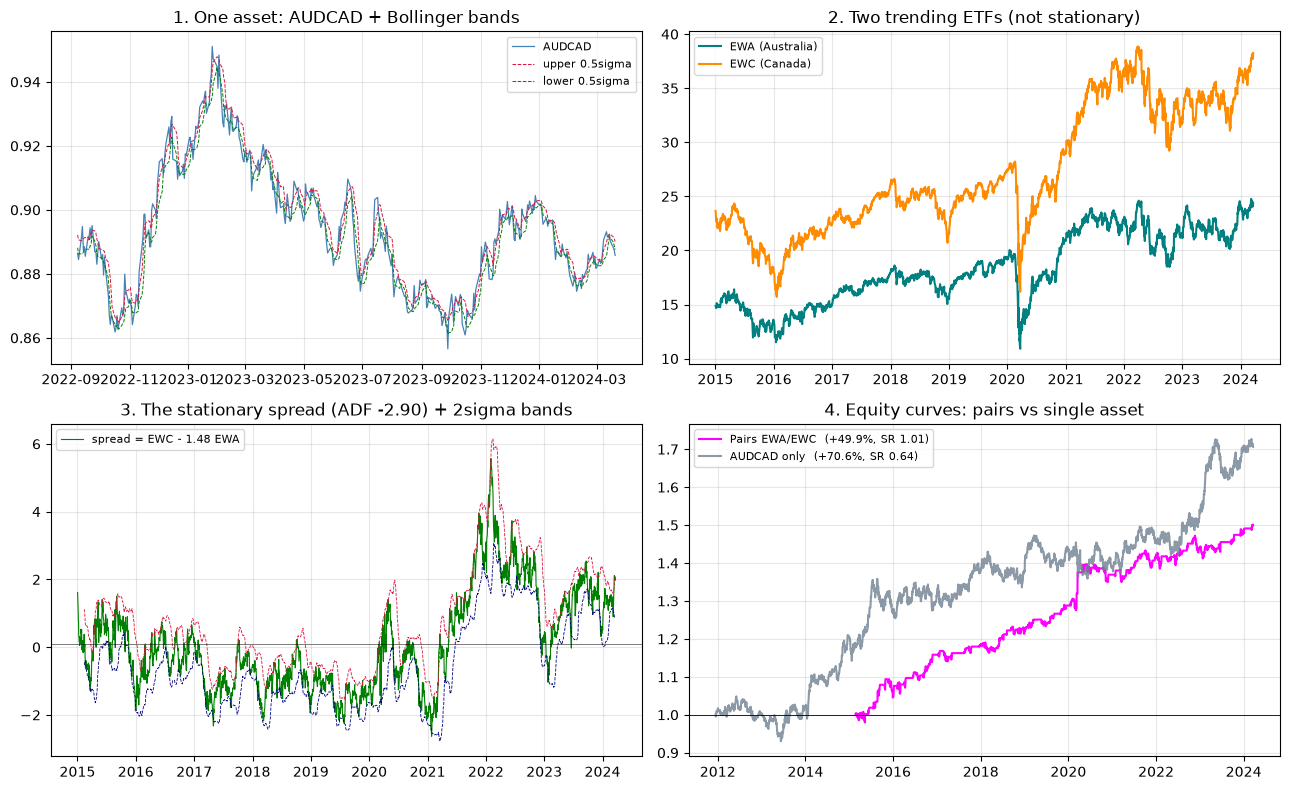

saved chart_1_pairs.png


In [10]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

# (1) AUDCAD + bands (last 400 bars for readability)
w = df_a.iloc[-400:]
ax[0,0].plot(w.index, w.Close, color='steelblue', lw=.9, label='AUDCAD')
ax[0,0].plot(w.index, w.upper_band, color='crimson', lw=.7, ls='--', label='upper 0.5sigma')
ax[0,0].plot(w.index, w.lower_band, color='green',   lw=.7, ls='--', label='lower 0.5sigma')
ax[0,0].set_title('1. One asset: AUDCAD + Bollinger bands'); ax[0,0].legend(fontsize=8)

# (2) EWA & EWC
ax[0,1].plot(df.index, df.EWA, label='EWA (Australia)', color='teal')
ax[0,1].plot(df.index, df.EWC, label='EWC (Canada)',    color='darkorange')
ax[0,1].set_title('2. Two trending ETFs (not stationary)'); ax[0,1].legend(fontsize=8)

# (3) spread + bands
ax[1,0].plot(df.index, df.spread, color='green', lw=.8, label='spread = EWC - 1.48 EWA')
ax[1,0].plot(df.index, df.upper_band, color='crimson', lw=.6, ls='--')
ax[1,0].plot(df.index, df.lower_band, color='navy',    lw=.6, ls='--')
ax[1,0].axhline(df.spread.mean(), color='k', lw=.6, alpha=.6)
ax[1,0].set_title('3. The stationary spread (ADF -2.90) + 2sigma bands'); ax[1,0].legend(fontsize=8)

# (4) equity curves
ax[1,1].plot(df.index, df.cumulative_returns, color='magenta', label='Pairs EWA/EWC  (+49.9%, SR 1.01)')
ax[1,1].plot(df_a.index, df_a.cumulative_returns, color='slategray', alpha=.8, label='AUDCAD only  (+70.6%, SR 0.64)')
ax[1,1].axhline(1, color='k', lw=.6)
ax[1,1].set_title('4. Equity curves: pairs vs single asset'); ax[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('chart_1_pairs.png', dpi=110, bbox_inches='tight', facecolor='white')
plt.show()
print('saved chart_1_pairs.png')

---
### Recap — what EFS-02 actually proved on its own data
- **Stationarity** (ADF) is the gate: a series is tradable for reversion only if it reverts. AUDCAD passes weakly (−2.57, 90%).
- **Cointegration** lets us *manufacture* a stationary spread from two non-stationary ETFs (hedge 1.48, spread ADF −2.90).
- The **same Bollinger reversion** run on the spread (pairs) gave a **smoother** return than on a single asset
  (DD −4.41% vs −11.29%) — the second leg hedges market risk.
- **Cointegration ≠ correlation.** Correlation is about returns moving together short-term; cointegration is about the
  *spread* staying stationary long-term. Pick pairs by economic logic (same sector / common factors), then confirm with ADF.
- **Risk:** stat-arb is *not* riskless — a cointegration can break (LTCM, 1998). Use stop-losses and diversify across pairs.

*Next steps suggested in class: try the AUDCAD logic on EURCHF, and the pairs logic on Kotak Bank vs HDFC Bank.*


---

# Additive source-backed continuation

The original notebook cells above are preserved. The first added cell supplies local statsmodels fallbacks for validation only.


# EFS-02 resource addendum

This additive notebook preserves the original notebook and adds source-backed validation tables for stationarity, cointegration, pair selection, and risk controls.

In [ ]:
import pandas as pd
from pathlib import Path
base = Path('.')
files = ['efs02_source_pdf_inventory.csv','efs02_source_zip_inventory.csv','efs02_data_inventory.csv','efs02_stationarity_diagnostics.csv','efs02_pair_strategy_metrics.csv','efs02_cointegration_vs_correlation.csv','efs02_pair_selection_controls.csv','efs02_risk_management_controls.csv']
data = {f: pd.read_csv(base / f) for f in files}
{k: v.shape for k, v in data.items()}

## 1. Source and data inventory

The local code folder has AUDCAD, EURCHF, EWA, and EWC from the EFS-02 source packet.

In [ ]:
print(data['efs02_source_pdf_inventory.csv'][['file','pages','keyword_hits']].to_string(index=False))
print(data['efs02_source_zip_inventory.csv'].groupby('role').size().to_string())
print(data['efs02_data_inventory.csv'].to_string(index=False))
assert data['efs02_data_inventory.csv']['file'].str.contains('AUDCAD').any()
assert data['efs02_source_zip_inventory.csv']['role'].str.contains('notebook').any()

## 2. Stationarity and pair metrics

The spread is the object being traded. The individual assets can be non-stationary while the residual spread is stationary.

In [ ]:
diag = data['efs02_stationarity_diagnostics.csv']
metrics = data['efs02_pair_strategy_metrics.csv']
print(diag.to_string(index=False))
print(metrics.to_string(index=False))
assert diag['series'].str.contains('EWC - hedge').any()
assert metrics['strategy'].str.contains('EWA/EWC').any()

## 3. Cointegration versus correlation

Correlation is a screen. Cointegration is the trading gate because the spread must mean-revert.

In [ ]:
coin = data['efs02_cointegration_vs_correlation.csv']
select = data['efs02_pair_selection_controls.csv']
risk = data['efs02_risk_management_controls.csv']
print(coin.to_string(index=False))
print(select.to_string(index=False))
print(risk.to_string(index=False))
assert coin['concept'].str.contains('Correlation').any()
assert risk['risk'].str.contains('breakdown', case=False).any()